<a href="https://www.kaggle.com/code/raynaldyu/fifa-world-cup-2026-prediction?scriptVersionId=323617067" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ⚽ FIFA World Cup 2026 — Match Outcome Prediction

A machine learning pipeline that predicts the outcome (Home Win / Draw / Away Win) of every FIFA World Cup 2026 group stage match. Built around a custom team rating system, macroeconomic context features, official FIFA ranking data, and a heavily regularized XGBoost classifier tuned specifically on World Cup match patterns.

---
## 📁 Project Structure

```
├── datasets/
│   ├── results.csv              # International match results 1872–2026
│   ├── gdpandpop_data.csv       # GDP & population per team per year
│   ├── fifa_ranking-2024.csv    # Official FIFA rankings
│   └── former_names.csv         # Country name mappings
│
├── fifa-world-cup-2026-prediction.ipynb   # Main notebook
└── README.md
```
---
## 🔧 Pipeline Overview

```
Raw Data
   │
   ├─ Merge results + GDP/Population + FIFA Rankings
   ├─ Standardise former country names (e.g. West Germany → Germany)
   ├─ Interpolate missing macroeconomic values by year per team
   ├─ Inject parent-state macroeconomic fallback (e.g. Andalusia → Spain)
   │
   ├─ Train / Val / Test Split
   │     Train : year ≤ 2021        (~149k matches)
   │     Val   : 2022 – 2026-06-10  (~4.4k matches, includes WC 2022)
   │     Test  : FIFA World Cup 2026 fixtures
   │
   ├─ PRISM Rating System  ──────────────────────────────────────────────┐
   │     Build chronological ratings on train set                        │
   │     Snapshot pre-match state for each row (zero leakage)            │
   │     Inject rating features into train / val / test                  │
   │     Rebuild ratings on all pre-2026 data for test inference         │
   └──────────────────────────────────────────────────────────────────────┘
   │
   ├─ Feature Engineering
   ├─ XGBoost Training  (multi:softprob, 3 classes)
   ├─ Draw Threshold Optimisation
   └─ WC 2026 Predictions
```

---
## 📊 Results
| *Metric* | *Score* |
| :--- | :--- |
| Validation Accuracy (raw) | 58.48% |
| Validation Accuracy (draw-tuned) | *58.55%* |
| Validation Log Loss | 0.8998 |
| Validation Set | All international matches 2022 – June 2026 |

---

For a complete breakdown of the methodology and code, please visit the [project repository on GitHub](https://github.com/raynaldyu-pixel/FIFA-World-Cup-2026-Prediction).

# Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Cleaning and Merging data

In [2]:
result_data = pd.read_csv("/kaggle/input/datasets/martj42/international-football-results-from-1872-to-2017/results.csv")
macro_data = pd.read_csv("/kaggle/input/datasets/raynaldyu/gdp-and-pop-for-international-football/gdpandpop_data.csv")
former_names = pd.read_csv("/kaggle/input/datasets/martj42/international-football-results-from-1872-to-2017/former_names.csv")
ranking_data = pd.read_csv("/kaggle/input/datasets/cashncarry/fifaworldranking/fifa_ranking-2024-06-20.csv")

In [3]:
macro_data.isnull().sum()

date                       0
home_team                  0
away_team                  0
home_score                72
away_score                72
tournament                 0
city                       0
country                    0
neutral                    0
population_team         8031
population_opp          8157
gdp_per_capita_team    14627
gdp_per_capita_opp     15192
dtype: int64

In [4]:
macro_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'population_team',
       'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp'],
      dtype='object')

In [5]:
def to_datetime(data):
    data['date'] = pd.to_datetime(data['date'])
    return data
    
to_datetime(result_data)
to_datetime(macro_data)

ranking_data['rank_date'] = pd.to_datetime(ranking_data['rank_date'])

In [6]:
ranking_data.sort_values(by='rank_date', ascending=False)

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
67471,1.0,Argentina,ARG,1860.14,1858.00,0,CONMEBOL,2024-06-20
67339,27.0,Hungary,HUN,1529.00,1532.20,1,UEFA,2024-06-20
67337,25.0,Austria,AUT,1560.03,1554.86,0,UEFA,2024-06-20
67336,12.0,Morocco,MAR,1669.44,1661.42,-1,CAF,2024-06-20
67335,104.0,Madagascar,MAD,1203.66,1185.86,-5,CAF,2024-06-20
...,...,...,...,...,...,...,...,...
109,132.0,Estonia,EST,3.00,0.00,132,UEFA,1992-12-31
108,133.0,Bangladesh,BAN,3.00,0.00,133,AFC,1992-12-31
107,134.0,Mauritania,MTN,3.00,0.00,134,CAF,1992-12-31
106,135.0,Cabo Verde,CPV,3.00,0.00,135,CAF,1992-12-31


## Add GDP & Population

In [7]:
macro_cols = [
    'date', 'home_team', 'away_team', 
    'population_team', 'population_opp', 
    'gdp_per_capita_team', 'gdp_per_capita_opp'
]

dataset = pd.merge(
    result_data,
    macro_data[macro_cols],
    on=['date', 'home_team', 'away_team'],
    how='left'
)

missing_macro = dataset['gdp_per_capita_team'].isna().sum()
total_matches = len(dataset)
print("Merge Completed!!")
dataset.head()

Merge Completed!!


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN


## Change Former names country to their current

In [8]:
name_mapping = dict(zip(former_names['former'], former_names['current']))

dataset['home_team'] = dataset['home_team'].replace(name_mapping)
dataset['away_team'] = dataset['away_team'].replace(name_mapping)

print(f"Successfully loaded a mapping dictionary of {len(name_mapping)} former names.")
dataset.head()

Successfully loaded a mapping dictionary of 36 former names.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN


# Dealing with Missing Value

In [9]:
for feature in dataset:    
    missing_macro = dataset[feature].isna().sum()
    avg = (missing_macro/len(dataset[feature]))*100
    total_matches = len(dataset)
    print(f"Out of {total_matches} matches, {feature} has {missing_macro} or {avg:.2f}% missing values.")

Out of 49348 matches, date has 0 or 0.00% missing values.
Out of 49348 matches, home_team has 0 or 0.00% missing values.
Out of 49348 matches, away_team has 0 or 0.00% missing values.
Out of 49348 matches, home_score has 72 or 0.15% missing values.
Out of 49348 matches, away_score has 72 or 0.15% missing values.
Out of 49348 matches, tournament has 0 or 0.00% missing values.
Out of 49348 matches, city has 0 or 0.00% missing values.
Out of 49348 matches, country has 0 or 0.00% missing values.
Out of 49348 matches, neutral has 0 or 0.00% missing values.
Out of 49348 matches, population_team has 8035 or 16.28% missing values.
Out of 49348 matches, population_opp has 8157 or 16.53% missing values.
Out of 49348 matches, gdp_per_capita_team has 14631 or 29.65% missing values.
Out of 49348 matches, gdp_per_capita_opp has 15192 or 30.79% missing values.


we will ignore home_score and away_score missing value since its just the latest and soon to be played game.

In [10]:
# Add Year and Month feature
dataset['year']  = dataset['date'].dt.year
dataset['month'] = dataset['date'].dt.month

## Analyse missing data

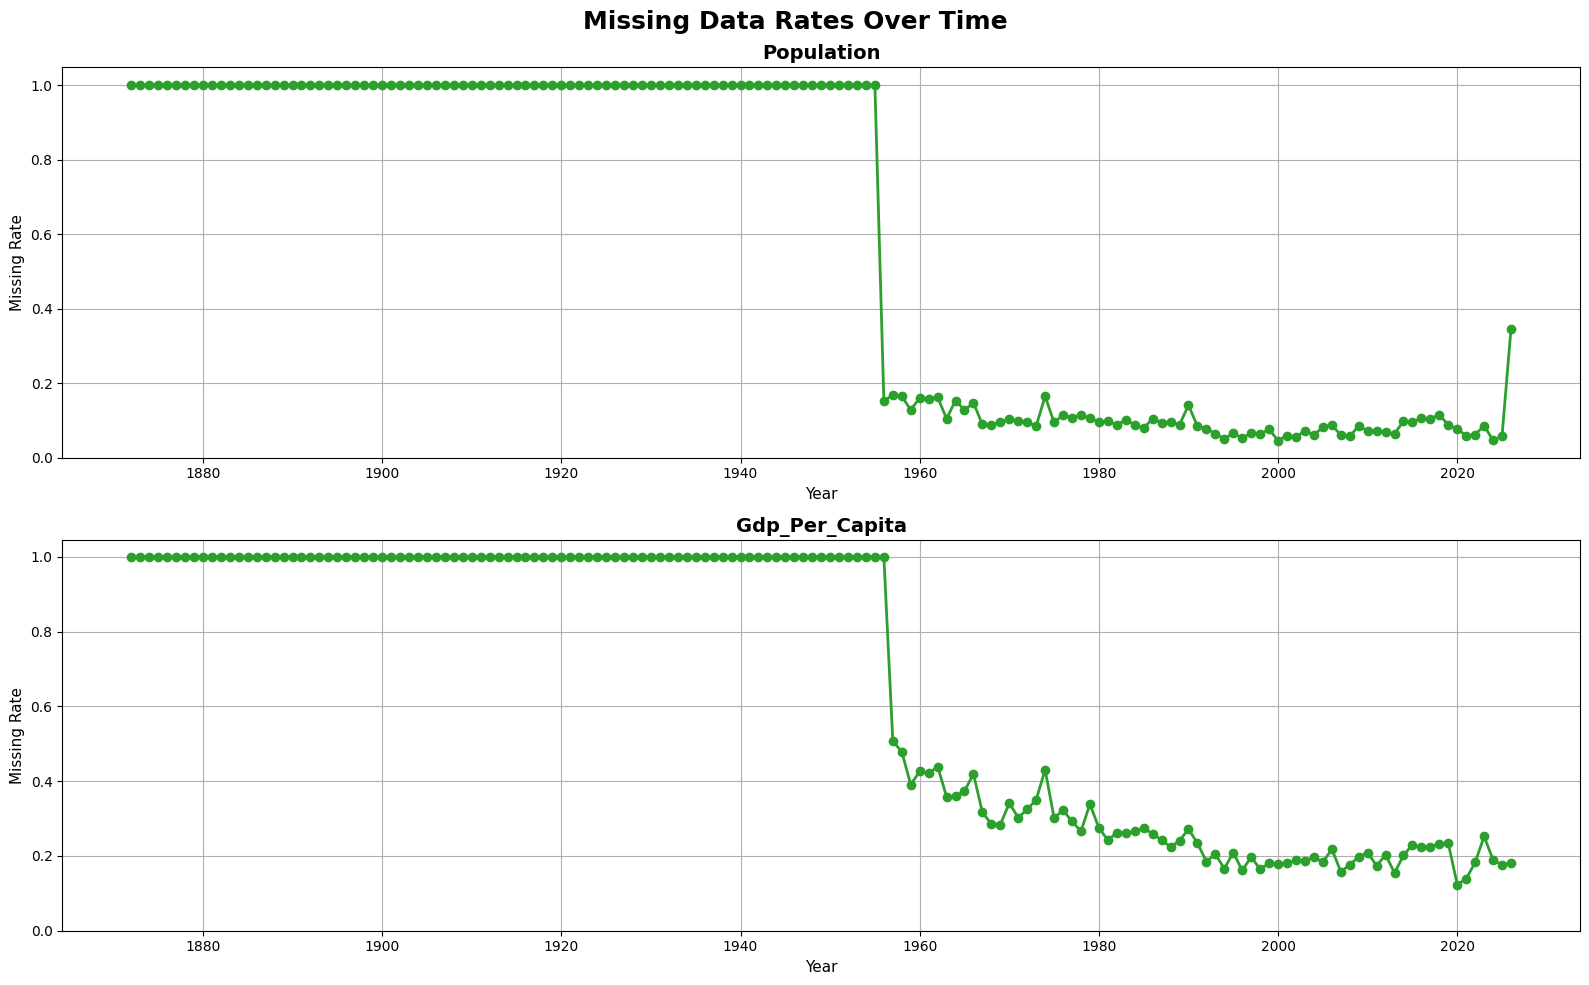

In [11]:
#1. Only take team since opp is just mirror of team dataset
missing_features = [
    'population_team',
    'gdp_per_capita_team',
]

#2. Calculate missing rate by year
missing_rates_by_year = dataset.groupby(dataset['date'].dt.year)[missing_features].apply(
    lambda x:x.isnull().mean()
)

#3. Cleanup column names for clean titles
clean_names = [col.replace('_team','').title() for col in missing_rates_by_year.columns]
missing_rates_by_year.columns = clean_names

#4. Create 2x1 subplot
fig, axes = plt.subplots(2,1, figsize=(16,10))

#5. Flatten to loop easily
axes = axes.flatten()

#6. Loop through features and plot
for i, feature in enumerate(missing_rates_by_year.columns):
    #Plot Both features
    ax = axes[i]
    ax.plot(missing_rates_by_year[feature], marker='o', linewidth=2,color='#2ca02c')

    #Format Title and Label
    ax.set_title(f'{feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year',fontsize= 11)
    ax.set_ylabel('Missing Rate', fontsize=11)

    #Force Y to start from 0 and Set Grid
    ax.set_ylim(bottom=0)
    ax.grid(True)

#7. Add main title for entire graphic and adjust spacing
plt.suptitle('Missing Data Rates Over Time', fontsize=18, fontweight='bold')
plt.tight_layout()

#8. Display plot
plt.show()

Question to be asked

In [12]:
dataset.groupby('home_team')['population_team'].apply(lambda x: x.isnull().mean())

home_team
Abkhazia         1.000000
Afghanistan      0.020833
Albania          0.057692
Alderney         1.000000
Algeria          0.002817
                   ...   
Yugoslavia       1.000000
Zambia           0.020833
Zanzibar         1.000000
Zimbabwe         0.044335
Åland Islands    1.000000
Name: population_team, Length: 325, dtype: float64

In [13]:
#1. When does the complete absence of data ends for gdp and population?
filtered_data = dataset[dataset['year'].isin([1955,1956, 1957, 1958, 2026])]
display(filtered_data.groupby('year')[['gdp_per_capita_team', 'population_team']].apply(lambda x: x.isnull().mean()))

#2. What countries are never recorded?
missing_rates = dataset.groupby('home_team')[['gdp_per_capita_team', 'population_team']].apply(lambda x: x.isnull().mean())
filtered_rates = missing_rates[(missing_rates['gdp_per_capita_team'] == 1) & (missing_rates['population_team'] == 1)]
display(filtered_rates)

,gdp_per_capita_team,population_team
year,,
1955,1.000000,1.000000
1956,1.000000,0.153061
1957,0.506787,0.167421
1958,0.478723,0.164894
2026,0.181435,0.345992


,gdp_per_capita_team,population_team
home_team,,
Abkhazia,1.0,1.0
Alderney,1.0,1.0
Andalusia,1.0,1.0
Arameans Suryoye,1.0,1.0
Artsakh,1.0,1.0
...,...,...
Yorkshire,1.0,1.0
Yoruba Nation,1.0,1.0
Yugoslavia,1.0,1.0


# Decision

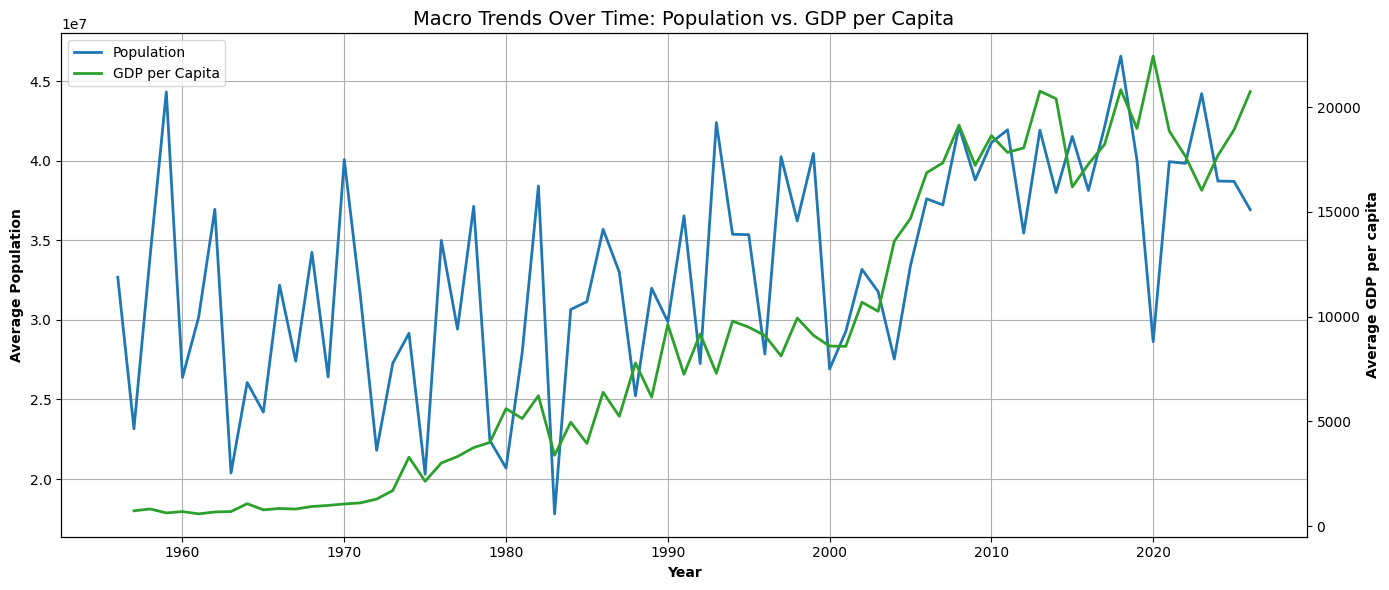

In [14]:
time_series_data = dataset.groupby('year')[['population_team','gdp_per_capita_team']].mean().reset_index() #reset_index take out the index back to feature

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2=ax1.twinx() #create a dual Y-axis plot (With its own Independent Y-Axis)

# Plot Population on the Left Y-Axis
ax1.set_xlabel('Year', fontweight = 'bold')
ax1.set_ylabel('Average Population',fontweight='bold')
ax1.plot(time_series_data['year'], time_series_data['population_team'], color='tab:blue', linewidth=2, label='Population')
ax1.grid(True)

# Plot GDP per capita on the Right Y-Axis
ax2.set_ylabel('Average GDP per capita', fontweight='bold')
ax2.plot(time_series_data['year'], time_series_data['gdp_per_capita_team'], color='tab:green', linewidth=2, label='GDP per Capita')

# Add Title
plt.title('Macro Trends Over Time: Population vs. GDP per Capita', fontsize=14)
fig.tight_layout() 

# Add Legend
line_1, label_1 = ax1.get_legend_handles_labels()
line_2, label_2 = ax2.get_legend_handles_labels()
ax1.legend(line_1 + line_2, label_1 + label_2, loc='upper left')

plt.show()

In [15]:
dataset.to_csv("dataset.csv")

In [16]:
dataset.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,year,month
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN,1872,11
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN,1873,3
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN,1874,3
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN,1875,3
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN,1876,3


## Interpolation through Geographical Features

## Add home_parent_state and Away_parent_state

In [17]:
# 1. Get a list of every single unique team in the dataset
all_teams = pd.concat([dataset['home_team'], dataset['away_team']]).unique()

# 2. Build the Universal Parent Mapping
parent_mapping = {}

for team in all_teams:
    # Look ONLY at matches where this team played at "home" (neutral == False)
    true_home_matches = dataset[(dataset['home_team'] == team) & (dataset['neutral'] == False)]
    
    if not true_home_matches.empty:
        # The most frequent venue country is their sovereign parent state
        parent_country = true_home_matches['country'].mode()[0]
        parent_mapping[team] = parent_country
    else:
        # Edge case: If a team ONLY ever played at neutral venues, they are their own parent
        parent_mapping[team] = team

# 3. Inject the mappings as brand new features
dataset['home_parent_state'] = dataset['home_team'].map(parent_mapping)
dataset['away_parent_state'] = dataset['away_team'].map(parent_mapping)

# 4. Quick verification
print("Feature injection complete! Let's check a regional team:")
verify_df = dataset[dataset['home_team'] == 'Andalusia'][['home_team', 'home_parent_state', 'country']].head(1)
print(verify_df)

Feature injection complete! Let's check a regional team:
     home_team home_parent_state country
788  Andalusia             Spain   Spain


In [18]:
#interpolate by year
def interpolate_macro_features(df_raw, feats, team_col='home_team'):
    df = df_raw.copy().sort_values([team_col, 'date'])

    for feat in feats:
        df[feat] = (
            df.set_index('year')
                .groupby(team_col)[feat]
                .transform(lambda x: x.interpolate(method='index').ffill())
                .values
        )
    return df

In [19]:
macro_cols = ['population_team','population_opp',
          'gdp_per_capita_team', 'gdp_per_capita_opp']
cleaned_data = interpolate_macro_features(dataset, 
    feats=macro_cols)

In [20]:
print("=== Remaining Nulls ===")
print(cleaned_data[macro_cols].isnull().sum().to_string())

=== Remaining Nulls ===
population_team         7968
population_opp          4487
gdp_per_capita_team    14482
gdp_per_capita_opp      5086


In [21]:
cleaned_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'population_team',
       'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'year',
       'month', 'home_parent_state', 'away_parent_state'],
      dtype='object')

## Inject parent feature to Macro

In [22]:
def inject_parent_feature(df, team_col, parent_col, pop_col, gdp_col):
    df = df.copy()

    #1. Build Macro database from Sovereign States using the passed columns
    sovereign_mask = df[team_col] == df[parent_col]
    sovereign_db = df[sovereign_mask][[team_col, 'year', pop_col, gdp_col]]
    sovereign_db.columns = ['parent_state', 'year', 'pop', 'gdp']

    #2. Clean Lookup table
    macro_db = sovereign_db.dropna().drop_duplicates(subset=['parent_state', 'year'])

    #3. Merge the exact year parent data on dataset
    df = df.merge(macro_db, left_on=[parent_col, 'year'], right_on=['parent_state','year'], how='left')

    #4. Overwrite the macro data ONLY for regional teams
    is_regional = df[team_col] != df[parent_col]
    df.loc[is_regional, pop_col] = df.loc[is_regional, 'pop']
    df.loc[is_regional, gdp_col] = df.loc[is_regional, 'gdp']

    # 5. Drop the temporary merge columns
    df = df.drop(columns=['parent_state', 'pop', 'gdp'])

    df = df.sort_values('date').reset_index(drop=True)
    
    return df

In [23]:
# 1. Inject Home Team Data
cleaned_data = inject_parent_feature(
    df=cleaned_data, 
    team_col='home_team', 
    parent_col='home_parent_state', 
    pop_col='population_team', 
    gdp_col='gdp_per_capita_team'
)

# 2. Inject Away Team Data
cleaned_data = inject_parent_feature(
    df=cleaned_data, 
    team_col='away_team', 
    parent_col='away_parent_state', 
    pop_col='population_opp', 
    gdp_col='gdp_per_capita_opp'
)

cleaned_data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,year,month,home_parent_state,away_parent_state
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN,1872,11,Scotland,England
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN,1873,3,England,Scotland
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN,1874,3,Scotland,England
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,NaN,NaN,NaN,NaN,1875,3,England,Scotland
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN,NaN,1876,3,Scotland,England


--- Numerical Verification ---
home_team     Andalusia         Spain
year                                 
2002       17025.531983  17025.531983
2003       21463.442658  21463.442658
2004       24861.282796  24861.282796
2005       26419.296864  26419.296864
2007       32549.970979  32549.970979


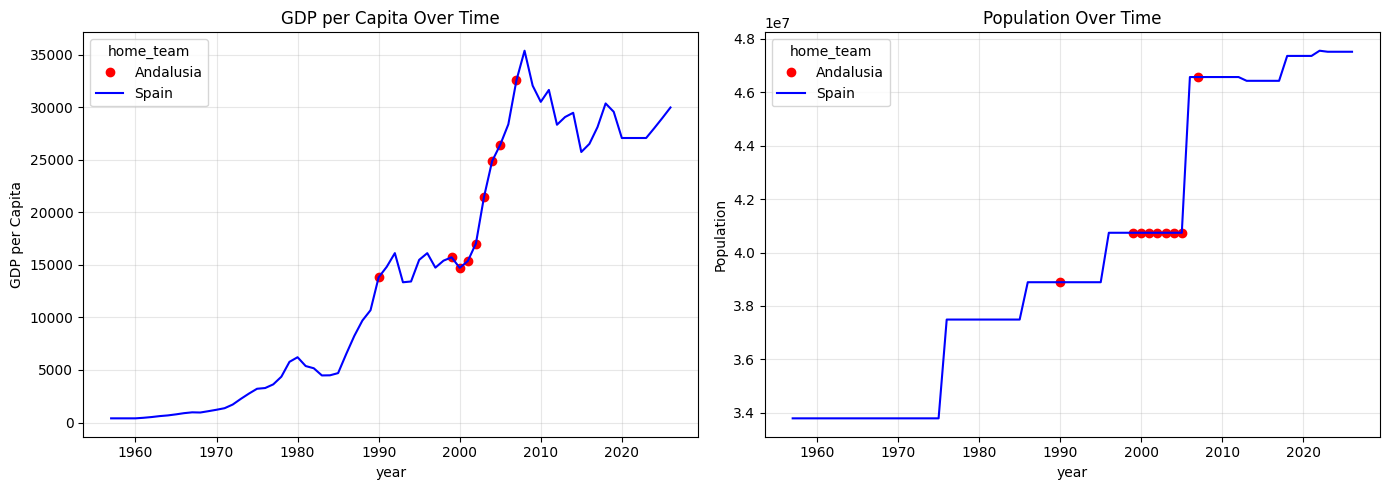

In [24]:
# Verify Andalusia successfully inherited Spain’s macroeconomic data

# 1. Filter the dataset for Spain and Andalusia (using home matches for a clean timeline)
teams_to_compare = ['Spain', 'Andalusia']
subset = cleaned_data[cleaned_data['home_team'].isin(teams_to_compare)].copy()

# 2. Keep only the relevant columns and drop duplicate years 
# (We only need one data point per year to draw the economic curve)
comparison_df = subset[['year', 'home_team', 'gdp_per_capita_team', 'population_team']]
comparison_df = comparison_df.drop_duplicates(subset=['year', 'home_team']).sort_values('year')

# 3. Pivot the tables so years are the rows and teams are the columns
gdp_pivot = comparison_df.pivot(index='year', columns='home_team', values='gdp_per_capita_team')
pop_pivot = comparison_df.pivot(index='year', columns='home_team', values='population_team')

# 4. Print the raw numbers for a quick sanity check (showing the last 5 years Andalusia played)
print("--- Numerical Verification ---")
print(gdp_pivot.dropna(subset=['Andalusia']).tail())

# 5. Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot GDP
gdp_pivot.plot(ax=axes[0], style={'Spain': '-b', 'Andalusia': 'ro'})
axes[0].set_title('GDP per Capita Over Time')
axes[0].set_ylabel('GDP per Capita')
axes[0].grid(True, alpha=0.3)

# Plot Population
pop_pivot.plot(ax=axes[1], style={'Spain': '-b', 'Andalusia': 'ro'})
axes[1].set_title('Population Over Time')
axes[1].set_ylabel('Population')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

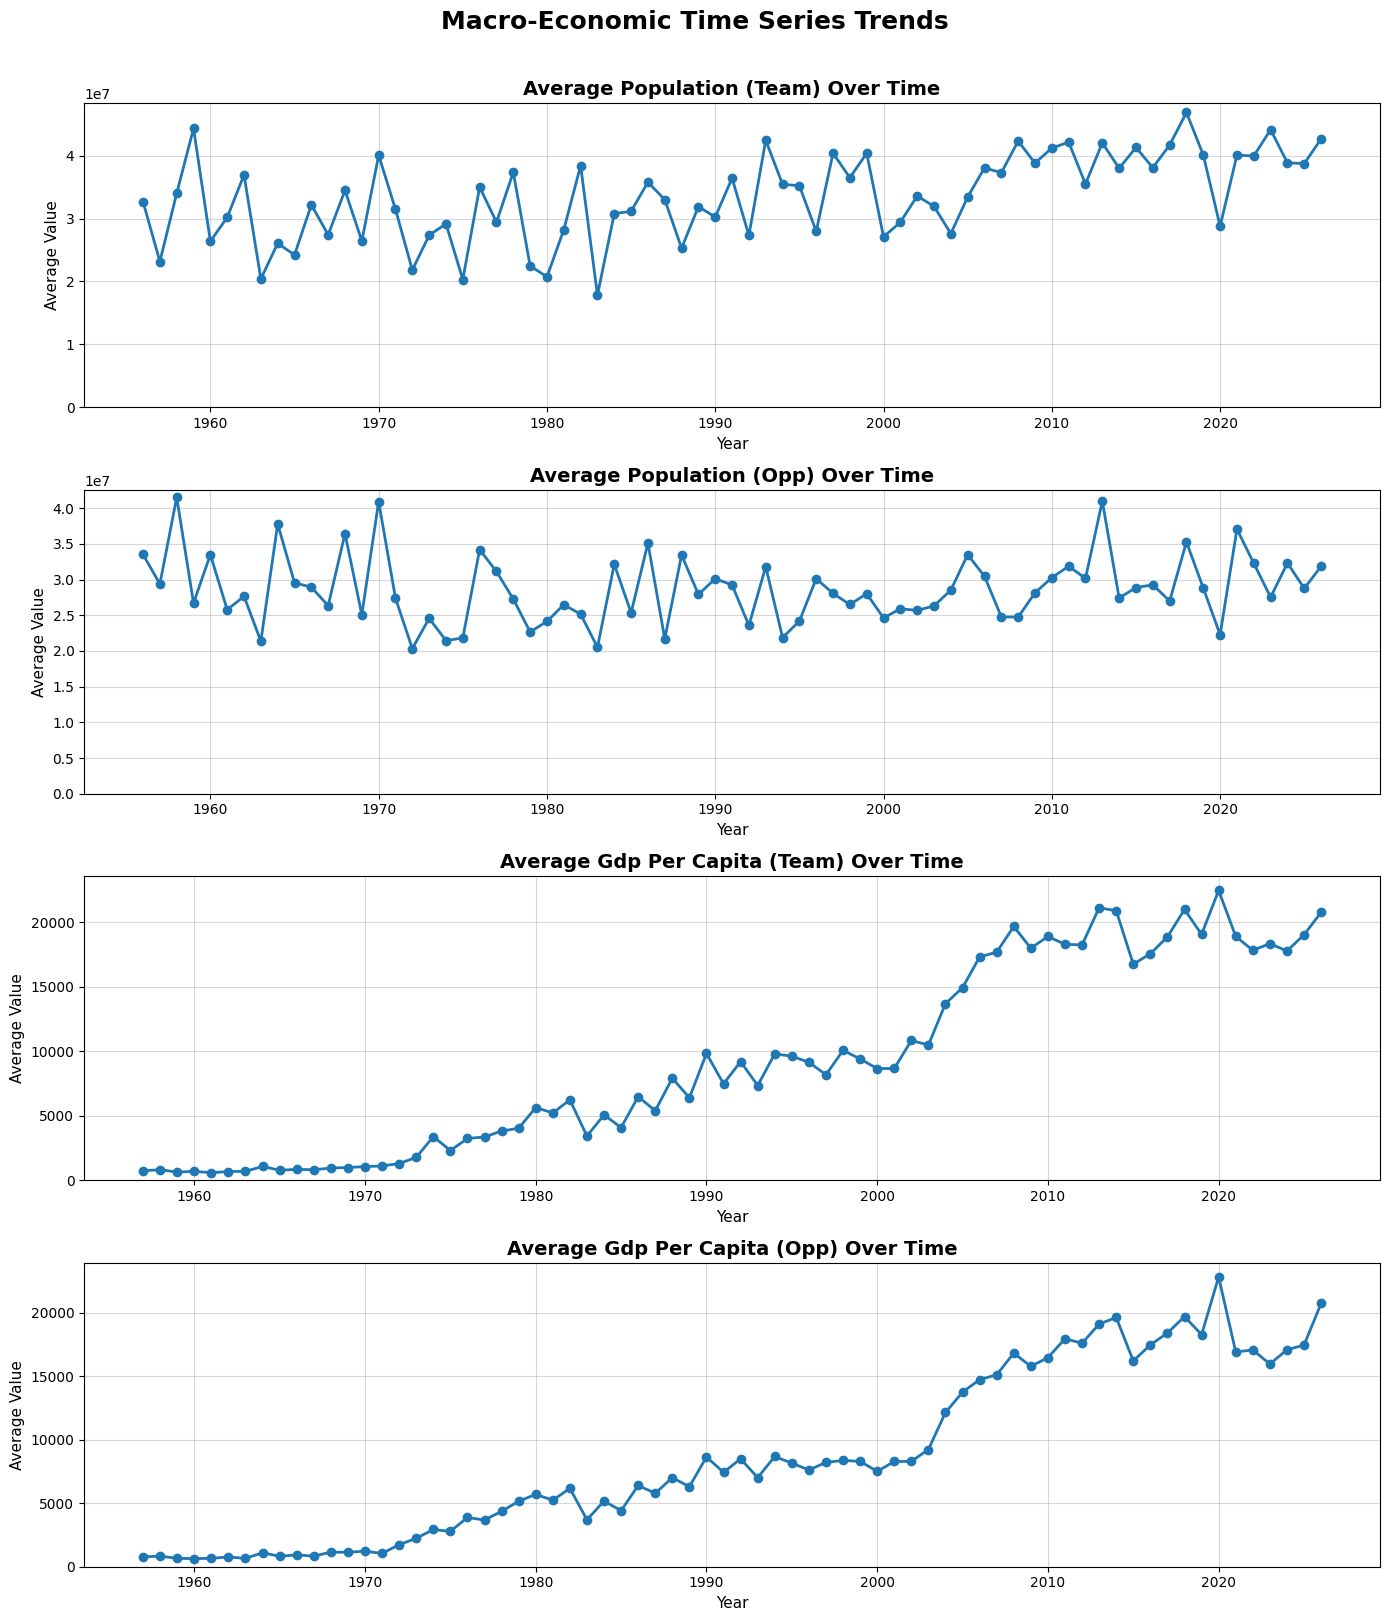

In [25]:
yearly_trend = cleaned_data.groupby('year')[macro_cols].mean()

clean_names = [col.replace('_team', ' (Team)').replace('_opp', ' (Opp)')
               .replace('_', ' ').title() for col in macro_cols]

fig, axes = plt.subplots(nrows=len(macro_cols), ncols=1, figsize=(14, 4 *len(macro_cols)))

for i, feature in enumerate(macro_cols):
    ax = axes[i]
    #Plot the time series
    ax.plot(yearly_trend.index, yearly_trend[feature], marker='o', linewidth=2, color='#1f77b4')

    #Format
    ax.set_title(f'Average {clean_names[i]} Over Time', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average Value', fontsize=11)

    #Force Y-Axis to start at 0
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.5)

# Add Title
plt.suptitle('Macro-Economic Time Series Trends', fontsize=18, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

# Train Val Test Split

In [26]:
# Train data: before last world cup
training_data = cleaned_data[cleaned_data['year'] <= 2021].copy()

# Val data: After 2010 and strictly before June 11, 2026 (Before world cup 2026)
validation_data = cleaned_data[(cleaned_data['year'] > 2021) & (cleaned_data['date'] < '2026-06-11')].copy()

# Setup Custom Rating (PRISM)
This rating is inspired by EDA + Elo + Berrar Rating system

In [27]:
training_data['tournament'].value_counts().head(15)

tournament
Friendly                                17127
FIFA World Cup qualification             7771
UEFA Euro qualification                  2586
African Cup of Nations qualification     2049
FIFA World Cup                            900
Copa América                              837
AFC Asian Cup qualification               728
African Cup of Nations                    689
CECAFA Cup                                620
CFU Caribbean Cup qualification           608
Merdeka Tournament                        595
British Home Championship                 523
Gulf Cup                                  380
AFC Asian Cup                             370
Asian Games                               368
Name: count, dtype: int64

In [28]:
# Official FIFA Match Importance Multipliers (I-Factor)
fifa_importance_weights = {
    'Friendly': 1.0,                                    
    'UEFA Nations League': 1.5,                         
    'FIFA World Cup qualification': 2.5,                
    'UEFA Euro qualification': 2.5,
    'Copa América qualification': 2.5,
    'African Cup of Nations qualification': 2.5,
    'AFC Asian Cup qualification': 2.5,
    'CONCACAF Championship qualification': 2.5,
    'African Cup of Nations': 3.5,                      
    'AFC Asian Cup': 3.5,
    'UEFA Euro': 4.0,                                   
    'Copa América': 4.0,
    'CONCACAF Championship': 4.0,
    'FIFA World Cup': 5.0                               
}

In [29]:
def get_default_rating():
    return {'attack':1.0, 'defense':1.0, 'outcome': 0.5, 'matches_played': 0}

def build_historical_rating(train_df, base_alpha=0.05, importance_weights=fifa_importance_weights, default_weight=1.2):
    state = defaultdict(get_default_rating)

    # 1. Protect the original index so we can restore it later on
    df = train_df.copy()
    df['_original_order'] = range(len(df))

    # Sort chronologically
    df = df.sort_values('date')

    # Pre-allocate lists for extreme speed
    i1, i2, i3, i4, i5, i6 = [], [], [], [], [], []
    home_matches, away_matches = [], []

    # Extract numpy arrays for the loop
    homes = df['home_team'].values
    aways = df['away_team'].values
    h_goals = df['home_score'].values
    a_goals = df['away_score'].values
    tournaments = df['tournament'].values

    # 2. The Core Chronological Loop
    for home, away, home_goals, away_goals, tourney in zip(homes, aways, h_goals, a_goals, tournaments):
        # A. Snapshot the pre-match state
        i1.append(state[home]['attack'])
        i2.append(state[home]['defense'])
        i3.append(state[away]['attack'])
        i4.append(state[away]['defense'])
        i5.append(state[home]['outcome'])
        i6.append(state[away]['outcome'])
        home_matches.append(state[home]['matches_played'])
        away_matches.append(state[away]['matches_played'])

        # B. Dynamic Match Importance (I-Factor)
        if importance_weights:
            weight = importance_weights.get(tourney, default_weight)
        else:
            weight = 1.0
            
        # Calculate the dynamic alpha for THIS specific match
        match_alpha = min(base_alpha * weight, 1.0)
        
        # C. Match Outcome Logic
        if home_goals > away_goals:
            r_home, r_away = 1.0, 0.0
        elif home_goals == away_goals:
            r_home, r_away = 0.5, 0.5
        else:
            r_home, r_away = 0.0, 1.0

        # D. Opponent-Adjusted Performance Calculation
        capped_h = min(home_goals, 6)
        capped_a = min(away_goals, 6)

        # Home performance depends on Away defense/attack
        perf_attack_home  = capped_h / max(0.2, state[away]['defense'])
        perf_defense_home = capped_a / max(0.2, state[away]['attack'])
        
        # Away performance depends on Home defense/attack
        perf_attack_away  = capped_a / max(0.2, state[home]['defense'])
        perf_defense_away = capped_h / max(0.2, state[home]['attack'])

        # D. Apply Exponential Moving Average (EMA) Updates
        state[home]['attack'] = (match_alpha * perf_attack_home) + ((1 - match_alpha) * state[home]['attack'])
        state[home]['defense'] = (match_alpha * perf_defense_home) + ((1 - match_alpha) * state[home]['defense'])
        state[home]['outcome'] = (match_alpha * r_home)            + ((1 - match_alpha) * state[home]['outcome'])

        state[away]['attack']  = (match_alpha * perf_attack_away)  + ((1 - match_alpha) * state[away]['attack'])
        state[away]['defense'] = (match_alpha * perf_defense_away) + ((1 - match_alpha) * state[away]['defense'])
        state[away]['outcome'] = (match_alpha * r_away)            + ((1 - match_alpha) * state[away]['outcome'])

        # E. Increment Match Counters
        state[home]['matches_played'] += 1
        state[away]['matches_played'] += 1

    # 3. Map the pre-match snapshots back to the DataFrame
    df['home_attack_rating']   = i1
    df['home_defense_rating']  = i2
    df['away_attack_rating']   = i3
    df['away_defense_rating']  = i4
    df['home_outcome_rating']  = i5
    df['away_outcome_rating']  = i6
    df['home_historical_matches'] = home_matches
    df['away_historical_matches'] = away_matches

    # 4. Restore original dataset order and drop the temporary column
    df = df.sort_values('_original_order').drop(columns=['_original_order'])
    
    return df, state

In [30]:
def build_tournament_rating_fallback(rating_state_dict, train_df):
    """
    Builds the Tier 3 (Tournament) and Tier 4 (Global) safety nets.
    """
    ignore_tournaments = ['Friendly', 'FIFA World Cup'] 
    regional_df = train_df[~train_df['tournament'].isin(ignore_tournaments)]
    
    team_tournament_map = {}
    # Adapted to map tournaments for both home and away teams in the unmirrored dataset
    for col in ['home_team', 'away_team']:
        sub = regional_df[[col, 'tournament']].dropna().drop_duplicates(subset=[col])
        for _, row in sub.iterrows():
            team_tournament_map[row[col]] = row['tournament']

    tourney_stats = defaultdict(lambda: {'attack': [], 'defense': [], 'outcome': []})
    for team, stats in rating_state_dict.items():
        tourney = team_tournament_map.get(team, 'Unknown')
        tourney_stats[tourney]['attack'].append(stats['attack'])
        tourney_stats[tourney]['defense'].append(stats['defense'])
        tourney_stats[tourney]['outcome'].append(stats['outcome'])

    tourney_fallback = {}
    for tourney, vals in tourney_stats.items():
        if len(vals['attack']) > 0:
            tourney_fallback[tourney] = {
                'attack':  np.mean(vals['attack']),
                'defense': np.mean(vals['defense']),
                'outcome': np.mean(vals['outcome']),
                'matches_played': 0
            }

    all_attacks  = [s['attack']  for s in rating_state_dict.values()]
    all_defenses = [s['defense'] for s in rating_state_dict.values()]
    all_outcomes = [s['outcome'] for s in rating_state_dict.values()]
    
    # Tier 4: Global Baseline mathematically upgraded to 0.5
    tourney_fallback['__global__'] = {
        'attack':  np.mean(all_attacks) if all_attacks else 1.0,
        'defense': np.mean(all_defenses) if all_defenses else 1.0,
        'outcome': np.mean(all_outcomes) if all_outcomes else 0.5,
        'matches_played': 0
    }
    
    return tourney_fallback
    
def inject_rating_features(df, rating_state_dict, parent_mapping, tourney_fallback):
    df = df.copy()
    # Handle tuple if state is passed directly from the builder function
    actual_dict = rating_state_dict[1] if isinstance(rating_state_dict, tuple) else rating_state_dict

    def get_rating(team, tournament):
        # Tier 1: Direct Match
        if team in actual_dict:
            return actual_dict[team]

        # Tier 2: Parent Country Inheritance
        parent = parent_mapping.get(team, team)
        if parent != team and parent in actual_dict:
            parent_stats = actual_dict[parent].copy()
            parent_stats['matches_played'] = 0 # Mark as new to the model
            return parent_stats

        # Tier 3: Regional Tournament Average
        if tourney_fallback and tournament in tourney_fallback:
            return tourney_fallback[tournament]

        # Tier 4: Global Baseline (0.5 Outcome)
        if tourney_fallback:
            return tourney_fallback.get('__global__', {'attack': 1.0, 'defense': 1.0, 'outcome': 0.5, 'matches_played': 0})
            
        return {'attack': 1.0, 'defense': 1.0, 'outcome': 0.5, 'matches_played': 0}

    # Extract the tournament for the fallback tiers
    tournaments = df['tournament'].tolist()
    
    # Unmirrored dataset mapping
    home_ratings = [get_rating(t, trny) for t, trny in zip(df['home_team'], tournaments)]
    away_ratings = [get_rating(o, trny) for o, trny in zip(df['away_team'], tournaments)]

    # Injecting clean column names for the Home Team
    df['home_attack_rating']      = [r['attack']         for r in home_ratings]
    df['home_defense_rating']     = [r['defense']        for r in home_ratings]
    df['home_outcome_rating']     = [r['outcome']        for r in home_ratings]
    df['home_historical_matches'] = [r['matches_played'] for r in home_ratings]
    
    # Injecting clean column names for the Away Team
    df['away_attack_rating']      = [r['attack']         for r in away_ratings]
    df['away_defense_rating']     = [r['defense']        for r in away_ratings]
    df['away_outcome_rating']     = [r['outcome']        for r in away_ratings]
    df['away_historical_matches'] = [r['matches_played'] for r in away_ratings]

    return df
        

In [31]:
# 1. Build the ratings chronologically using the dynamic FIFA weights
train_data, rating_state_dict = build_historical_rating(
    train_df=training_data, 
    base_alpha=0.05, 
    importance_weights=fifa_importance_weights
)

# 2. Calculate Regional and Global fallback averages from the new smart dictionary
tourney_fallback_dict = build_tournament_rating_fallback(
    rating_state_dict=rating_state_dict, 
    train_df=train_data
)

# 3. Inject the final features using the 4-Tier Hierarchy
val_data = inject_rating_features(
    df=validation_data, 
    rating_state_dict=rating_state_dict, 
    parent_mapping=parent_mapping, 
    tourney_fallback=tourney_fallback_dict
)

print("Pipeline Complete! XGBoost is ready to feast.")

Pipeline Complete! XGBoost is ready to feast.


In [32]:
def print_world_power_rankings(rating_state_dict, min_matches=20):
    # 1. Convert the final dictionary into a DataFrame
    rankings_df = pd.DataFrame.from_dict(rating_state_dict, orient='index')
    
    # 2. Filter out teams that haven't played enough historical matches
    rankings_df = rankings_df[rankings_df['matches_played'] >= min_matches]
    
    print(f"=== GLOBAL POWER RANKINGS (Min {min_matches} Matches) === \n")
    
    # --- BEST RATINGS ---
    # Attack: Higher is better (More goals scored relative to opponent defense)
    print("TOP 5: BEST ATTACK")
    print(rankings_df[['attack', 'matches_played']].sort_values(by='attack', ascending=False).head(5), "\n")
    
    # Defense: LOWER is better (Fewer goals conceded relative to opponent attack)
    print("TOP 5: BEST DEFENSE")
    print(rankings_df[['defense', 'matches_played']].sort_values(by='defense', ascending=True).head(5), "\n")
    
    # Outcome: Higher is better (Closer to 1.0 = High win rate)
    print("TOP 5: BEST OUTCOME (MOMENTUM)")
    print(rankings_df[['outcome', 'matches_played']].sort_values(by='outcome', ascending=False).head(5), "\n")
    
    print("-" * 50, "\n")
    
    # --- WORST RATINGS ---
    print("BOTTOM 5: WORST ATTACK")
    print(rankings_df[['attack', 'matches_played']].sort_values(by='attack', ascending=True).head(5), "\n")
    
    print("BOTTOM 5: WORST DEFENSE")
    print(rankings_df[['defense', 'matches_played']].sort_values(by='defense', ascending=False).head(5), "\n")
    
    print("BOTTOM 5: WORST OUTCOME (MOMENTUM)")
    print(rankings_df[['outcome', 'matches_played']].sort_values(by='outcome', ascending=True).head(5), "\n")

# Run the function on your final dictionary
print_world_power_rankings(rating_state_dict, min_matches=50)

=== GLOBAL POWER RANKINGS (Min 50 Matches) === 

TOP 5: BEST ATTACK
           attack  matches_played
France   4.475572             880
Belgium  4.442524             803
England  4.402940            1036
Germany  4.236341             979
Serbia   3.979568             299 

TOP 5: BEST DEFENSE
            defense  matches_played
England    0.107677            1036
Argentina  0.133955            1020
Brazil     0.166374            1010
Italy      0.213875             844
Spain      0.231580             729 

TOP 5: BEST OUTCOME (MOMENTUM)
            outcome  matches_played
Morocco    0.894784             548
Iran       0.856046             561
England    0.847978            1036
Algeria    0.833355             554
Argentina  0.833253            1020 

-------------------------------------------------- 

BOTTOM 5: WORST ATTACK
                                attack  matches_played
Anguilla                      0.125887              67
United States Virgin Islands  0.135821              5

In [33]:
train_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'population_team',
       'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'year',
       'month', 'home_parent_state', 'away_parent_state', 'home_attack_rating',
       'home_defense_rating', 'away_attack_rating', 'away_defense_rating',
       'home_outcome_rating', 'away_outcome_rating', 'home_historical_matches',
       'away_historical_matches'],
      dtype='object')

In [34]:
val_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'population_team',
       'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'year',
       'month', 'home_parent_state', 'away_parent_state', 'home_attack_rating',
       'home_defense_rating', 'home_outcome_rating', 'home_historical_matches',
       'away_attack_rating', 'away_defense_rating', 'away_outcome_rating',
       'away_historical_matches'],
      dtype='object')

# Feature Engineering

In [35]:
def feature_engineering(data):
    df = data.copy()

    df['match_importance'] = df['tournament'].map(fifa_importance_weights).fillna(1.2)
    
    df['home_advantage'] = 1 - df['neutral'].astype(int)
    
    df['gdp_ratio'] = df['gdp_per_capita_team'] / (df['gdp_per_capita_opp'] + 1e-5)
    df['pop_diff'] = df['population_team'] - df['population_opp']

    df['matches_ratio'] = (df['home_historical_matches'] + 1) / (df['away_historical_matches'] + 1)
    df['experience_advantage'] = df['home_historical_matches'] - df['away_historical_matches']

    # Create the mathematical "Gaps" between the teams
    df['attack_vs_defense_diff'] = df['home_attack_rating'] - df['away_defense_rating']
    df['defense_vs_attack_diff'] = df['home_defense_rating'] - df['away_attack_rating']
    df['overall_momentum_diff']  = df['home_outcome_rating'] - df['away_outcome_rating']

    return df

In [36]:
train_data = feature_engineering(train_data)
val_data = feature_engineering(val_data)

In [37]:
train_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'population_team',
       'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'year',
       'month', 'home_parent_state', 'away_parent_state', 'home_attack_rating',
       'home_defense_rating', 'away_attack_rating', 'away_defense_rating',
       'home_outcome_rating', 'away_outcome_rating', 'home_historical_matches',
       'away_historical_matches', 'match_importance', 'home_advantage',
       'gdp_ratio', 'pop_diff', 'matches_ratio', 'experience_advantage',
       'attack_vs_defense_diff', 'defense_vs_attack_diff',
       'overall_momentum_diff'],
      dtype='object')

In [38]:
train_data

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,population_team,...,away_historical_matches,match_importance,home_advantage,gdp_ratio,pop_diff,matches_ratio,experience_advantage,attack_vs_defense_diff,defense_vs_attack_diff,overall_momentum_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,NaN,...,0,1.0,1,NaN,NaN,1.000000,0,0.000000,0.000000,0.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,NaN,...,1,1.0,1,NaN,NaN,1.000000,0,0.000000,0.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,NaN,...,2,1.0,1,NaN,NaN,1.000000,0,0.000000,0.000000,-0.050000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,NaN,...,3,1.0,1,NaN,NaN,1.000000,0,0.000000,0.000000,-0.002500
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,NaN,...,4,1.0,1,NaN,NaN,1.000000,0,0.000000,0.000000,0.002375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44851,2021-12-26,Thailand,Vietnam,0.0,0.0,AFF Championship,Kallang,Singapore,True,71475664.0,...,246,1.2,0,2.579894,-25173021.0,3.234818,552,0.219821,-0.028477,0.149115
44852,2021-12-29,Indonesia,Thailand,0.0,4.0,AFF Championship,Kallang,Singapore,True,271857970.0,...,799,1.2,0,0.538424,200382306.0,0.833750,-133,0.013864,1.236289,0.005656
44853,2021-12-30,Sudan,Ethiopia,2.0,3.0,Friendly,Limbé,Cameroon,True,44440486.0,...,375,1.0,0,0.519489,-72750425.0,1.135638,51,-0.285306,0.163805,-0.084126
44854,2021-12-30,Mauritania,Burkina Faso,0.0,0.0,Friendly,Abu Dhabi,United Arab Emirates,True,4498604.0,...,402,1.0,0,1.983828,-17024022.0,0.555831,-179,0.088301,-0.116421,-0.318294


# Model

In [39]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss, accuracy_score

# 1. PREP THE TARGETS AND MATRICES
def create_target(df):
    conditions = [
        (df['home_score'] > df['away_score']),
        (df['home_score'] == df['away_score']),
        (df['home_score'] < df['away_score'])
    ]
    choices = [2, 1, 0] # 2 = Home Win, 1 = Draw, 0 = Away Win
    return np.select(conditions, choices, default=1)

train_data['target'] = create_target(train_data)
val_data['target']   = create_target(val_data)

# Drop raw strings and columns that would cause data leakage & not needed
drop_cols = [
    'target', 'home_score', 'away_score', 'home_team', 'away_team', 
    'home_parent_state', 'away_parent_state', 'city', 'country',
    'year', 'date', 'month', 'tournament', 'gdp_per_capita_team',
    'gdp_per_capita_opp', 'population_team', 'population_opp', 'neutral'
]

X_train = train_data.drop(columns=drop_cols)
y_train = train_data['target']

X_val = val_data.drop(columns=drop_cols)
X_val = X_val[X_train.columns] # Enforce strict column order
y_val = val_data['target']

# 2. TRAIN THE HIGHLY REGULARIZED MODEL
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss', # track both log loss AND error rate
    learning_rate=0.01,      # Slower, more precise learning
    n_estimators=2000,       # High number of trees
    max_depth=3,             # Shallow trees to prevent memorizing random upsets
    min_child_weight=15,
    reg_lambda=5.0,          # Heavy L2 Regularization
    early_stopping_rounds=50, # MUST HAVE THIS! Stops training if val score drops
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("🚀 Training XGBoost Probability Engine...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

# Extract raw probabilities for the validation set
val_probs = xgb_model.predict_proba(X_val)
actual_targets = y_val.values

print("\n--- Raw Baseline Results ---")
print(f"Base Accuracy: {accuracy_score(y_val, xgb_model.predict(X_val)):.4f}")
print(f"Log Loss:      {log_loss(y_val, val_probs):.4f}")

🚀 Training XGBoost Probability Engine...
[0]	validation_0-mlogloss:1.04141	validation_1-mlogloss:1.05114
[100]	validation_0-mlogloss:0.96790	validation_1-mlogloss:0.97076
[200]	validation_0-mlogloss:0.94023	validation_1-mlogloss:0.94117
[300]	validation_0-mlogloss:0.92432	validation_1-mlogloss:0.92508
[400]	validation_0-mlogloss:0.91475	validation_1-mlogloss:0.91589
[500]	validation_0-mlogloss:0.90859	validation_1-mlogloss:0.91072
[600]	validation_0-mlogloss:0.90428	validation_1-mlogloss:0.90772
[700]	validation_0-mlogloss:0.90094	validation_1-mlogloss:0.90581
[800]	validation_0-mlogloss:0.89809	validation_1-mlogloss:0.90445
[900]	validation_0-mlogloss:0.89560	validation_1-mlogloss:0.90343
[1000]	validation_0-mlogloss:0.89333	validation_1-mlogloss:0.90265
[1100]	validation_0-mlogloss:0.89129	validation_1-mlogloss:0.90206
[1200]	validation_0-mlogloss:0.88938	validation_1-mlogloss:0.90155
[1300]	validation_0-mlogloss:0.88763	validation_1-mlogloss:0.90103
[1400]	validation_0-mlogloss:0.88

## Getting Best Draw Threshold

In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Get probabilities on validation set (not train — probs are overfit there) ──
val_probs  = xgb_model.predict_proba(X_val)
actual     = y_val.values  # 0=Away Win, 1=Draw, 2=Home Win

prob_away  = val_probs[:, 0]
prob_draw  = val_probs[:, 1]
prob_home  = val_probs[:, 2]
gap        = np.maximum(prob_home, prob_away) - prob_draw  # leader minus draw

eda        = pd.DataFrame({
    'gap':        gap,
    'prob_draw':  prob_draw,
    'actual':     actual,
    'is_draw':    (actual == 1).astype(int)
})

# ── Sweep both dimensions ──────────────────────────────────────────────────────
gap_values       = np.arange(0.00, 0.30, 0.01)
min_draw_values  = np.arange(0.20, 0.40, 0.02)

results = []
for gap_thresh in gap_values:
    for min_draw in min_draw_values:
        preds = []
        for pa, pd_, ph in zip(prob_away, prob_draw, prob_home):
            leading = max(ph, pa)
            if pd_ >= min_draw and (leading - pd_) <= gap_thresh:
                preds.append(1)
            elif ph >= pa:
                preds.append(2)
            else:
                preds.append(0)
        acc = np.mean(np.array(preds) == actual)
        draws_predicted = np.sum(np.array(preds) == 1)
        results.append({
            'gap_thresh':      round(gap_thresh, 2),
            'min_draw_prob':   round(min_draw, 2),
            'accuracy':        round(acc, 4),
            'draws_predicted': draws_predicted
        })

results_df = pd.DataFrame(results)
best       = results_df.loc[results_df['accuracy'].idxmax()]

print(f"Best combination:")
print(f"gap_threshold   = {best['gap_thresh']}")
print(f"min_draw_prob   = {best['min_draw_prob']}")
print(f"accuracy        = {best['accuracy']:.4f}")
print(f"draws predicted = {int(best['draws_predicted'])}")

Best combination:
gap_threshold   = 0.07
min_draw_prob   = 0.2
accuracy        = 0.5848
draws predicted = 279


In [41]:
# 3. OPTIMIZE THE POST-PROCESSING THRESHOLD
def apply_custom_threshold(probs, diff_threshold=0.08, min_draw_prob=0.36):
    preds = []
    for prob_away, prob_draw, prob_home in probs:
        leading_prob = max(prob_home, prob_away)
        gap = leading_prob - prob_draw

        if prob_draw >= min_draw_prob and gap <= diff_threshold:
            preds.append(1)
        elif prob_home >= prob_away:
            preds.append(2)
        else:
            preds.append(0)
    return np.array(preds)
    
# Use the best combination from your EDA heatmap
best_threshold    = best['gap_thresh']   # gap threshold
best_min_draw     = best['min_draw_prob']   # minimum draw probability — the guard

test_preds = apply_custom_threshold(val_probs)
acc = accuracy_score(actual_targets, test_preds)

print("Final Score for Validation Data:", acc)

Final Score for Validation Data: 0.5834841628959276


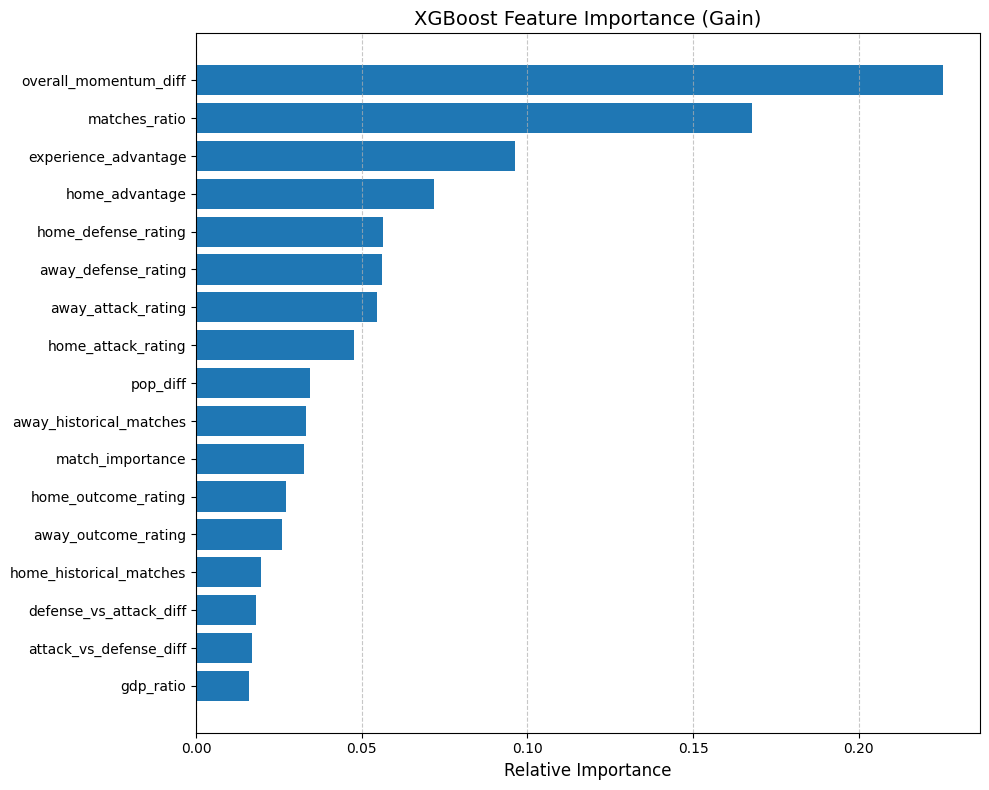

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from the trained model
importances = xgb_model.feature_importances_
features = X_train.columns

# Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#1f77b4')
plt.title("XGBoost Feature Importance (Gain)", fontsize=14)
plt.xlabel("Relative Importance", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# FIFA WORLD CUP 2026 Prediction

In [43]:
# ╔═══════════════════════════════════════════════════════╗
# ║           FIFA WORLD CUP 2026 Pipeline             ║
# ╚═══════════════════════════════════════════════════════╝

# 1. Prepare rating from all data before the World Cup 2026

full_pre_wc = cleaned_data[cleaned_data['date']<'2026-06-11'].copy()

_, rating_state_2026 = build_historical_rating(
    train_df = full_pre_wc,
    base_alpha=0.05, 
    importance_weights=fifa_importance_weights
)

tourney_fallback_2026 = build_tournament_rating_fallback(
    rating_state_dict = rating_state_2026,
    train_df = full_pre_wc
)

print(f"Ratings built from {len(full_pre_wc):,} matches up to 2026-06-10")
print(f"Teams rated: {len(rating_state_2026)}")

# 2. Grab the WC 2026 test matches 
test_data = cleaned_data[
    (cleaned_data['date'] >= '2026-06-11') &
    (cleaned_data['tournament'] == 'FIFA World Cup')
].copy()

print(f"Test matches found: {len(test_data)}")
print(test_data[['date', 'home_team', 'away_team']].head(10).to_string(index=False))

# 3. Inject Ratings
test_data = inject_rating_features(
    df=test_data,
    rating_state_dict=rating_state_2026,
    parent_mapping=parent_mapping,
    tourney_fallback=tourney_fallback_2026
)

# 4. Feature engineering 
test_data = feature_engineering(test_data)

# 5. Prepare X_test features 
safe_drop = [c for c in drop_cols if c in test_data.columns]
X_test = test_data.drop(columns=safe_drop)

# 6.reindex to exact columns and order as X_train, fills any missing column with 0 rather than crashing
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\n X_test shape: {X_test.shape}  |  X_train shape: {X_train.shape}")
print(f"Column mismatch check: {list(set(X_train.columns) - set(X_test.columns))}")

# 7. Predict with the best threshold
test_probs = xgb_model.predict_proba(X_test)
test_preds = apply_custom_threshold(test_probs, best_threshold, best_min_draw)

# 8.Build readable results DataFrame
outcome_map = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}

results_df = test_data[['date', 'home_team', 'away_team']].copy().reset_index(drop=True)
results_df['prob_home_win']      = (test_probs[:, 2] * 100).round(1)
results_df['prob_draw']          = (test_probs[:, 1] * 100).round(1)
results_df['prob_away_win']      = (test_probs[:, 0] * 100).round(1)
results_df['predicted_outcome']  = pd.Series(test_preds).map(outcome_map).values
results_df['confidence_%']       = results_df[['prob_home_win', 'prob_draw', 'prob_away_win']].max(axis=1)

print("\nFIFA WORLD CUP 2026 PREDICTIONS - Group Stage dataset is made")

Ratings built from 49,276 matches up to 2026-06-10
Teams rated: 333
Test matches found: 72
      date     home_team              away_team
2026-06-11   South Korea         Czech Republic
2026-06-11        Mexico           South Africa
2026-06-12        Canada Bosnia and Herzegovina
2026-06-12 United States               Paraguay
2026-06-13        Brazil                Morocco
2026-06-13     Australia                 Turkey
2026-06-13         Qatar            Switzerland
2026-06-13         Haiti               Scotland
2026-06-14   Netherlands                  Japan
2026-06-14        Sweden                Tunisia

 X_test shape: (72, 17)  |  X_train shape: (44856, 17)
Column mismatch check: []

FIFA WORLD CUP 2026 PREDICTIONS - Group Stage dataset is made


In [44]:
# 1. Define the 2026 Groups
group_mapping = {
    # Group A
    'Mexico': 'A', 'South Africa': 'A', 'South Korea': 'A', 'Czech Republic': 'A',
    # Group B
    'Canada': 'B', 'Bosnia and Herzegovina': 'B', 'Qatar': 'B', 'Switzerland': 'B',
    # Group C
    'United States': 'C', 'Paraguay': 'C', 'Australia': 'C', 'Turkey': 'C',
    # Group D
    'Brazil': 'D', 'Morocco': 'D', 'Haiti': 'D', 'Scotland': 'D',
    # Group E
    'Germany': 'E', 'Curaçao': 'E', 'Ivory Coast': 'E', 'Ecuador': 'E',
    # Group F
    'Netherlands': 'F', 'Japan': 'F', 'Sweden': 'F', 'Tunisia': 'F',
    # Group G
    'Belgium': 'G', 'Egypt': 'G', 'Iran': 'G', 'New Zealand': 'G',
    # Group H
    'Spain': 'H', 'Cape Verde': 'H', 'Saudi Arabia': 'H', 'Uruguay': 'H',
    # Group I
    'France': 'I', 'Iraq': 'I', 'Norway': 'I', 'Senegal': 'I',
    # Group J
    'Argentina': 'J', 'Algeria': 'J', 'Austria': 'J', 'Jordan': 'J',
    # Group K
    'Portugal': 'K', 'Colombia': 'K', 'DR Congo': 'K', 'Uzbekistan': 'K',
    # Group L
    'England': 'L', 'Croatia': 'L', 'Ghana': 'L', 'Panama': 'L'
}

# Map the groups to the home teams (since teams play within their own group)
results_df['Group'] = results_df['home_team'].map(group_mapping)

# 2. CALCULATE ACTUAL POINTS & EXPECTED POINTS (xPts)
results_df['home_points'] = np.where(results_df['predicted_outcome'] == 'Home Win', 3, 
                            np.where(results_df['predicted_outcome'] == 'Draw', 1, 0))
results_df['away_points'] = np.where(results_df['predicted_outcome'] == 'Away Win', 3, 
                            np.where(results_df['predicted_outcome'] == 'Draw', 1, 0))

results_df['home_xPts'] = (results_df['prob_home_win']/100 * 3) + (results_df['prob_draw']/100 * 1)
results_df['away_xPts'] = (results_df['prob_away_win']/100 * 3) + (results_df['prob_draw']/100 * 1)

# 3. BUILD THE STANDINGS TABLE WITH RANKS
home_stats = results_df[['Group', 'home_team', 'home_points', 'home_xPts']].rename(
    columns={'home_team': 'Team', 'home_points': 'Points', 'home_xPts': 'xPts'})
home_stats['Matches'] = 1; home_stats['W'] = (home_stats['Points'] == 3).astype(int); home_stats['D'] = (home_stats['Points'] == 1).astype(int); home_stats['L'] = (home_stats['Points'] == 0).astype(int)

away_stats = results_df[['Group', 'away_team', 'away_points', 'away_xPts']].rename(
    columns={'away_team': 'Team', 'away_points': 'Points', 'away_xPts': 'xPts'})
away_stats['Matches'] = 1; away_stats['W'] = (away_stats['Points'] == 3).astype(int); away_stats['D'] = (away_stats['Points'] == 1).astype(int); away_stats['L'] = (away_stats['Points'] == 0).astype(int)

all_stats = pd.concat([home_stats, away_stats])
standings = all_stats.groupby(['Group', 'Team']).sum().reset_index()
standings['xPts'] = standings['xPts'].round(2)

# Sort groups internally (Points first, then xPts breaks any dynamic ties)
standings = standings.sort_values(by=['Group', 'Points', 'xPts', 'W'], ascending=[True, False, False, False])
standings['Rank'] = standings.groupby('Group').cumcount() + 1

# 4. DISPLAY THE GROUP STAGE & MATCH MATH
print("\n🏆 FIFA WORLD CUP 2026 - GROUP STAGE PREDICTIONS 🏆")
for group_name in sorted(standings['Group'].dropna().unique()):
    print(f"\n" + "═"*85)
    print(f"🏅 GROUP {group_name} STANDINGS")
    print("═"*85)
    
    # 3a. Standings (No xPts displayed here)
    group_table = standings[standings['Group'] == group_name]
    print(group_table[['Rank', 'Team', 'Matches', 'W', 'D', 'L', 'Points']].to_string(index=False))
    
    print(f"\n📅 GROUP {group_name} MATCH PROBABILITIES")
    print("-" * 85)
    
    # 3b. Match Probabilities for this specific group
    group_matches = results_df[results_df['Group'] == group_name].copy()
    display_cols = [
        'date', 'home_team', 'away_team', 
        'prob_home_win', 'prob_draw', 'prob_away_win', 
        'predicted_outcome'
    ]
    print(group_matches[display_cols].to_string(index=False))
    print("\n")
    
# 5. THE WILDCARD MINI-LEAGUE (xPts strictly active here)
thirds = standings[standings['Rank'] == 3].copy()
thirds = thirds.sort_values(by=['Points', 'xPts'], ascending=[False, False])
thirds['Wildcard_Rank'] = range(1, len(thirds) + 1)

best_8_thirds = thirds.head(8).copy()
best_8_thirds['Path'] = 'Wildcard'
eliminated_thirds = thirds.tail(4).copy()

print("\n\n" + "═" * 70)
print("🃏 WILDCARD STANDINGS (3rd Place Teams) 🃏")
print("   Tiebreakers resolved using model Expected Points (xPts)")
print("═" * 70)
print("\n🟢 --- ADVANCING ---")
print(best_8_thirds[['Wildcard_Rank', 'Group', 'Team', 'Points', 'xPts']].to_string(index=False))
print("\n🔴 --- ELIMINATED ---")
print(eliminated_thirds[['Wildcard_Rank', 'Group', 'Team', 'Points', 'xPts']].to_string(index=False))

# 6. THE FINAL 32 QUALIFIED (Strictly Selected Columns)
top_2_teams = standings[standings['Rank'] <= 2].copy()
top_2_teams['Path'] = 'Top 2 Guaranteed'

# Combine Top 2 and the 8 surviving Wildcards
round_of_32 = pd.concat([top_2_teams, best_8_thirds])
round_of_32 = round_of_32.sort_values(by=['Group', 'Rank'])

print("\n")
print("=" * 60)
print("🎟️ ROAD TO THE ROUND OF 32 - QUALIFIED TEAMS 🎟️")
print("=" * 60)
# Strictly displays Group, Team, Points, and Path at the lowest part
print(round_of_32[['Group', 'Team', 'Points', 'Path']].to_string(index=False))
print("\n" + "=" * 70)
print(f"Total Teams Qualified: {len(round_of_32)} / 32")
print("=" * 70)


🏆 FIFA WORLD CUP 2026 - GROUP STAGE PREDICTIONS 🏆

═════════════════════════════════════════════════════════════════════════════════════
🏅 GROUP A STANDINGS
═════════════════════════════════════════════════════════════════════════════════════
 Rank           Team  Matches  W  D  L  Points
    1         Mexico        3  3  0  0       9
    2    South Korea        3  2  0  1       6
    3 Czech Republic        3  1  0  2       3
    4   South Africa        3  0  0  3       0

📅 GROUP A MATCH PROBABILITIES
-------------------------------------------------------------------------------------
      date      home_team      away_team  prob_home_win  prob_draw  prob_away_win predicted_outcome
2026-06-11    South Korea Czech Republic      56.599998  22.700001      20.700001          Home Win
2026-06-11         Mexico   South Africa      79.400002  15.300000       5.400000          Home Win
2026-06-18         Mexico    South Korea      58.400002  22.200001      19.400000          Home Win
2026